# Exploratory Data Analysis and Data Preparation

**Problem:** a digital bank must decide, per eligible client, which offer /
message / next step to present. Instead of fixed rules or long A/B tests, we build an
**adaptive offer-selection platform** (multi-armed bandit). This notebook explores the
reference dataset and prepares the client features + target for the model.

**Dataset:** Kaggle [`henriqueyamahata/bank-marketing`](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing)
(mirror of the UCI Bank Marketing dataset, Moro et al. 2014). Target `y` =
whether the client subscribed to a term deposit (conversion).

### 1. Load and understand the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import load_data, clean_data, build_preprocessor, split_data, FEATURE_COLUMNS

In [2]:
raw = load_data()
print("shape:", raw.shape)
print("columns:", list(raw.columns))

shape: (45211, 17)
columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### 2. Target distribution

Only ~12% of clients subscribed to the term deposit — a typical imbalanced
conversion problem.

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


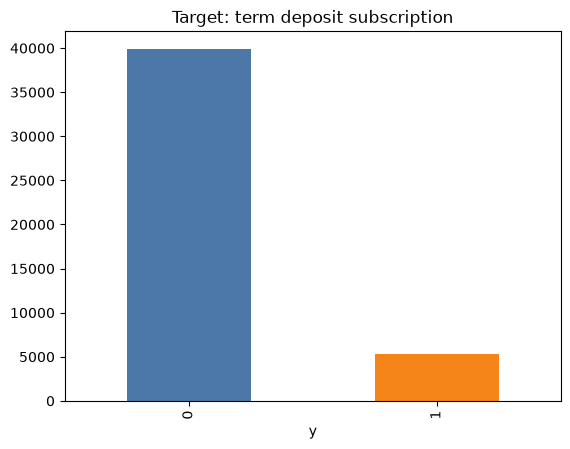

In [3]:
conv = raw["y"].value_counts(normalize=True) * 100
print(conv.round(2))
raw["y"].map({"yes": 1, "no": 0}).value_counts().plot.bar(
    title="Target: term deposit subscription", color=["#4C78A8", "#F58518"]
);

### 3. Missing / `unknown` values

Categoricals use `unknown` instead of NaN. We keep `unknown` as a real category
(it is informative: e.g. a client with unknown outcome was never contacted before).

In [4]:
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome"]
unknown = pd.DataFrame({c: (raw[c] == "unknown").sum() for c in cat_cols}, index=["unknown"])
print(unknown)

         job  marital  education  default  housing  loan  contact  poutcome
unknown  288        0       1857        0        0     0    13020     36959


### 4. Contact channel — the *action* the platform decides

`contact` (cellular / telephone / unknown) is not a client feature: it is the
channel the bank used, i.e. the **arm/action** our platform chooses. Clients
contacted by cellular convert at a higher rate.

conversion by contact channel:
 contact
cellular     0.149
telephone    0.134
unknown      0.041
Name: y, dtype: float64


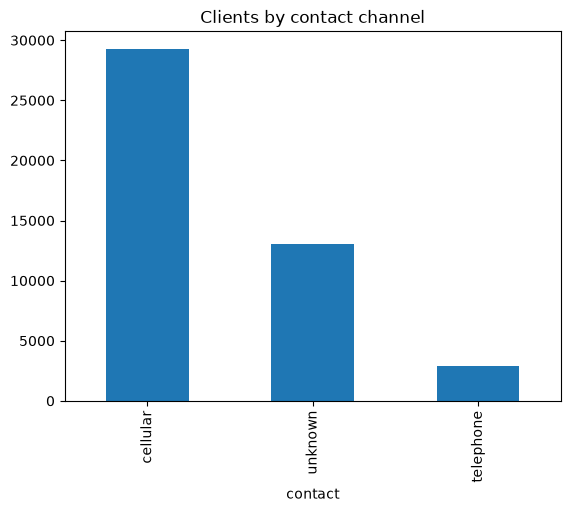

In [5]:
ch = raw.groupby("contact")["y"].apply(lambda s: (s == "yes").mean()).round(3)
print("conversion by contact channel:\n", ch)
raw["contact"].value_counts().plot.bar(title="Clients by contact channel");

### 5. Numeric features overview

In [6]:
raw.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 6. Leakage removal and preparation

Temporal leakage columns are dropped **before** modeling:

- `duration` — only known *after* the call; leaks the outcome (mandated by the rubric).
- `day` / `month` — encode the campaign period itself.

`pdays` / `previous` / `poutcome` refer to *previous* campaigns: legitimate client
history, kept but documented as a limitation. `contact` is the action, not a feature.

In [7]:
df = clean_data(raw)
print("after dropping leakage columns:", df.shape)
print("kept columns:", list(df.columns))

after dropping leakage columns: (45211, 14)
kept columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### 7. Final feature matrix and split

One-hot encode categoricals (unknown values become their own columns), standardize
numerics, and split 70/30 stratified on the target. The simulator is fit on the
train split; the bandit replays on the eval split.

In [8]:
X, y = df[FEATURE_COLUMNS], df["y"]
X_train, X_eval, y_train, y_eval = split_data(X, y)
pre = build_preprocessor().fit(X_train)
X_train_t, X_eval_t = pre.transform(X_train), pre.transform(X_eval)
print("train features:", X_train_t.shape)
print("eval  features:", X_eval_t.shape)

train features: (31647, 34)
eval  features: (13564, 34)


### Summary

- 45,211 clients, 17 raw columns; leakage columns removed -> 14 columns (incl. target and channel).
- Target is imbalanced (11.7% conversion); categoricals contain an informative `unknown` value.
- `contact` is the decision (arm), not a feature.
- Features are one-hot + standardized and split into train (70%) / eval (30%).